# Conceptualizing

### Understanding what we built, from the ground up

This notebook is a course, not a report. The reports are
`paper_walkthrough.ipynb` (the replication) and `method_comparison.ipynb` (the
methodological adjudication). Both of those state *what* was found. This one
explains *why any of it makes sense*, one question at a time.

**How it works.** You ask a question. The answer arrives as a block of cells
with a fixed set of elements, though not a fixed length:

| element | why it is there |
| --- | --- |
| **The question, sharpened** | half of understanding is knowing exactly what is being asked |
| **Intuition, before any code** | if it cannot be said in plain language it is not understood |
| **A concrete example** | small enough to hold in your head and check by hand |
| **A prediction prompt** | commit to an answer *before* running the cell |
| **Transparent code** | the naive version that shows the mechanism, not an API call |
| **Reconciliation** | what the result was, and why it may differ from your guess |
| **The tempting wrong answer** | named explicitly, then killed |
| **Takeaway and exercise** | one sentence to remember, one thing to try |

**Why the prediction step matters more than it looks.** Reading a correct answer
feels like learning and mostly is not. Committing to a guess first — even a wrong
one — produces markedly better retention, because a wrong prediction creates the
gap that the explanation then fills. When you hit a **PREDICT** cell, answer it
out loud or in a comment before running the next cell. Skipping it costs most of
the value of this notebook.

**Why wrong answers are shown deliberately.** In building this project two of my
own claims were adjudicated and refuted (`method_comparison.ipynb`, claims D and
H). Presenting only the clean path would misrepresent how any of this was
actually arrived at, and would leave you without the instinct for where the traps
are.

**Kernel.** Select `imp-pathinfo (.venv)`. The setup cell checks this and will
complain if it is wrong.

## Setup

One cell, deliberately small. Datasets and heavy objects load **on first use**
and are cached, so nothing is paid for until a question needs it.

In [1]:
import os, sys, math, json, time, itertools, warnings
warnings.filterwarnings('ignore')

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, os.path.join(ROOT, 'src'))
sys.path.insert(0, os.path.join(os.path.dirname(ROOT), 'index-deconvolution', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9})

# --- our own packages -------------------------------------------------------
from imp_pathinfo import causalbool_mirror as cbm     # the index-set mirror
from imp_pathinfo import method_comparison as mc      # the adjudication experiments
from imp_pathinfo import paper_values as pv           # the paper's published tables
from imp_pathinfo import analysis as an               # PUM, correlations, clustering
from imp_pathinfo.data import DATASET_ORDER, load_dataset
from imp_pathinfo.bdm_complexity import bdm_engine, graph_bdm

# --- the root project's index-set implementation ----------------------------
import causalbool as cb                                # forward method
import deconvolution as dc                             # exact inverse

# --- lazy, cached accessors -------------------------------------------------
_CACHE = {}

def data(name):
    # Load a MoleculeNet dataset on first use, then serve it from cache.
    if name not in _CACHE:
        _CACHE[name] = load_dataset(name)
    return _CACHE[name]

def bdm():
    # The BDM engine, created once.
    if 'bdm' not in _CACHE:
        _CACHE['bdm'] = bdm_engine()
    return _CACHE['bdm']

def PREDICT(question, options=None):
    # Print a prediction prompt. Answer it before running the next cell.
    bar = '=' * 74
    print(bar); print('PREDICT  ->  ' + question)
    if options:
        for i, o in enumerate(options, 1):
            print(f'            ({i}) {o}')
    print('            commit to an answer, then run the next cell')
    print(bar)

# --- a running map of what we have covered ----------------------------------
CONCEPTS = {}

def learned(name, one_line, depends_on=()):
    CONCEPTS[name] = dict(idea=one_line, depends_on=', '.join(depends_on) or '--')

def concept_map():
    return pd.DataFrame(CONCEPTS).T[['idea', 'depends_on']]

print('kernel  :', sys.executable)
assert '.venv' in sys.executable, 'select the "imp-pathinfo (.venv)" kernel'
print('numpy   :', np.__version__, '| pandas:', pd.__version__)
print('ready. datasets available:', DATASET_ORDER)
print('nothing loaded yet -- data() fetches on demand.')

kernel  : /Users/alberto/Documents/projects/CausalBool/imp-pathinfo-paper/.venv/bin/python
numpy   : 2.5.1 | pandas: 3.0.5
ready. datasets available: ['FreeSolv', 'ESOL', 'Lipophilicity', 'BACE', 'BBBP', 'ClinTox']
nothing loaded yet -- data() fetches on demand.


---

# The vocabulary, set straight

Before any question, the words. Several objects in this project look similar and
are routinely confused — including by me, earlier in this notebook's own history.
This table is the reference; everything below uses these terms and nothing else.

| term | what it actually is |
| --- | --- |
| **input repertoire** | the exhaustive enumeration of all $2^n$ input states of an $n$-component system |
| **perturbation** | setting the system to one of those input states — or flipping one bit of one state and re-running it |
| **output repertoire** | the $2^n \times n$ table of what every node outputs, for every input state |
| **isolated node output** | one *column* of the output repertoire: the behaviour of a single node across all perturbations |
| **index set** $\mathcal{I}_c$ | the inputs a node actually depends on |
| **free coordinates** $\mathcal{I}_{nc}$ | the *nodes* not involved in a query — the dimension the query cannot see |
| **sumandos** $\Omega$ | **decimal numbers**, not nodes: every subset sum of the weights $2^{i-1}$ of the free coordinates |
| **DecimalRepertoire** $L$ | **decimal numbers**: the anchor positions, one per assignment of the *involved* coordinates that satisfies the query |
| **Behaviour Table** | a research *instrument* (Chapter 4 of the thesis) whose columns transform an isolated node output until its regularities become visible |
| **behaviour formula** | the compressed expression at the foot of a Behaviour Table, e.g. "85 zeros, then twice the pattern 1,0, then 4 zeros…" |
| **pivot** $P(\mathcal{I}_c)$ | $\sum_{i \in \mathcal{I}_c} w(i)$ — the formal object that the Behaviour Table's sum column became |
| **`onPossibleBehaviour`** | the query: *where in the output repertoire do these nodes take these values?* Returns the compressed pair $(L, \Omega)$ |
| **`givePlaces`** / $\mathrm{Dec}(L,\Omega)$ | the unfolder $\{\ell + s\}$: add the **whole** sumandos list to **each** element of the DecimalRepertoire |

**Two distinctions to hold on to.**

*Data versus instrument.* The **output repertoire** is data — what the system
did. A **Behaviour Table** is an instrument — transformations applied to that
data to make a pattern visible to a human being. Question 0b is about why the
difference mattered historically.

*Nodes versus numbers.* **Sumandos are not nodes.** They are decimal offsets. In
the 7-node example of Question 0c the sumandos are
$\{0, 2, 8, 10, 32, 34, 40, 42\}$ — values far larger than the number of nodes,
because they are subset sums of the *weights* $2^{i-1}$ of the free coordinates.
Confusing the free coordinates $\{2,4,6\}$ with the sumandos they generate is
exactly the error corrected in Question 0c.

**Sources.** Behaviour Tables and behaviour formulae: `doc/Tesis-UNAM/tesis.pdf`,
Chapter 4. Pivots, offsets and $\mathrm{Dec}$: `papers/method/manuscript_formal/method_paper.pdf`,
with the computational account in `papers/method/manuscript_computational/comp_paper.pdf`.

---

# Question 0 — a worked example of the format

*You have not asked this one; I am answering it so you can judge the format
before we start, and because it is genuinely where everything begins.*

## **What is an "index set", and why does this entire project rest on it?**

### 1. Intuition first

Think of a recipe. To reproduce a dish you need exactly two things:

* **the ingredient list** — *which* things go in, and
* **the method** — *what you do* with them.

The CausalBool formalism makes precisely that claim about a system. For each
part of the system you need only:

* **the index set** — *which* other parts feed into it, and
* **the gate** — *what function* it computes on them.

That is it. The index set is the ingredient list. Nothing else about the rest of
the universe matters to that part.

This sounds almost too simple to be a research programme, and the reason it is
one is a consequence that is not obvious at all: **if a part only depends on its
index set, then everything else in the system is invisible to it** — and that
invisibility is something we can exploit computationally, and detect
experimentally by perturbation.

### 2. A concrete example

Four components, numbered 0 to 3. Component 3 is fed by components 0 and 2, and
by nothing else. Its gate is `OR`: it fires when either of them fires.

```
        0 ─────┐
               ├──> 3        index set of node 3 = {0, 2}
        2 ─────┘             gate of node 3      = OR

        1                    feeds nothing into 3
```

The system has 4 binary components, so its **input repertoire** has
2⁴ = 16 states, and its **output repertoire** is a 16 × 4 table.

In [2]:
C = [[0, 0, 0, 0],       # row k lists the inputs of node k
     [1, 0, 0, 0],       # node 1 <- node 0
     [0, 1, 0, 0],       # node 2 <- node 1
     [1, 0, 1, 0]]       # node 3 <- nodes 0 and 2
net = cb.Network(n=4, C=C, gates=['FALSE', 'NOT', 'NOT', 'OR'])

print('index set of node 3 :', net.connected_inputs(3))
print('gate of node 3      :', net.gates[3])
print('input repertoire    :', 2 ** net.n, 'states')

index set of node 3 : [0, 2]
gate of node 3      : OR
input repertoire    : 16 states


### 3. PREDICT — before you run anything

The **isolated output of node 3** is its column of the output repertoire: what it
outputs under every one of the 16 perturbations.

Written out in full that column has 16 entries. But how many of those entries are
*independent*? Node 3 is fed by 2 components.

**How many rows does node 3's behaviour genuinely require?**

In [3]:
PREDICT('How many independent rows does node 3\'s isolated output require?',
        ['16 — one per state of the whole input repertoire',
         '4 — one per state of its two inputs',
         '8 — something in between'])

PREDICT  ->  How many independent rows does node 3's isolated output require?
            (1) 16 — one per state of the whole input repertoire
            (2) 4 — one per state of its two inputs
            (3) 8 — something in between
            commit to an answer, then run the next cell


### 4. The code, written transparently

We compute the full output repertoire, take node 3's column, and then ask of each
bit: *does perturbing it change anything?*

**What "perturbing bit $i$" means concretely.** Take any input state, change bit
$i$ from 0 to 1 leaving all other bits untouched, and re-run the system. If node
3's output is the same for every such pair, then bit $i$ is invisible to node 3 —
it is not in its index set. If even one pair differs, bit $i$ is a pivot.

This is the same move the thesis makes on a larger scale: *"the behaviour is
computed by perturbing the system on all possible inputs"*.

In [4]:
rep = cb.repertoire(net)                      # output repertoire: 16 x 4
column = [rep[x][3] for x in range(16)]       # isolated output of node 3

repertoire_table = pd.DataFrame({
    'input state x': range(16),
    'input bits v0 v1 v2 v3': [' '.join(str((x >> i) & 1) for i in range(4)) for x in range(16)],
    'node 3 output': column,
})
display(repertoire_table)

,input state x,input bits v0 v1 v2 v3,node 3 output
0,0,0 0 0 0,0
1,1,1 0 0 0,1
2,2,0 1 0 0,0
3,3,1 1 0 0,1
4,4,0 0 1 0,1
5,5,1 0 1 0,1
6,6,0 1 1 0,1
7,7,1 1 1 0,1
8,8,0 0 0 1,0
9,9,1 0 0 1,1


In [5]:
# The perturbation test, done by hand: flip one bit, compare, repeat.
print('perturbation test on each bit of the input repertoire:')
connected, free = [], []
for i in range(4):
    pairs = [(x, x | (1 << i)) for x in range(16) if not (x >> i) & 1]
    changed = [(a, b) for a, b in pairs if column[a] != column[b]]
    if changed:
        connected.append(i)
        a, b = changed[0]
        print(f'  bit {i}: CONNECTED  -- e.g. state {a:2d} -> {b:2d} changes the output '
              f'{column[a]} -> {column[b]}   ({len(changed)}/{len(pairs)} perturbations bite)')
    else:
        free.append(i)
        print(f'  bit {i}: FREE       -- none of the {len(pairs)} perturbations changes anything')

print()
print('index set I_c (connected)  :', connected)
print('free coordinates I_nc      :', free)

# CAREFUL: the free coordinates are NODES. The *sumandos* are the decimal
# offsets they generate -- every subset sum of their weights 2^i.
weights_free = [2 ** i for i in free]
sumandos = sorted({sum(c) for r in range(len(weights_free) + 1)
                   for c in itertools.combinations(weights_free, r)})
print('weights of the free coords :', weights_free)
print('SUMANDOS (decimal offsets) :', sumandos, '  <- numbers, not nodes')

perturbation test on each bit of the input repertoire:
  bit 0: CONNECTED  -- e.g. state  0 ->  1 changes the output 0 -> 1   (4/8 perturbations bite)
  bit 1: FREE       -- none of the 8 perturbations changes anything
  bit 2: CONNECTED  -- e.g. state  0 ->  4 changes the output 0 -> 1   (4/8 perturbations bite)
  bit 3: FREE       -- none of the 8 perturbations changes anything

index set I_c (connected)  : [0, 2]
free coordinates I_nc      : [1, 3]
weights of the free coords : [2, 8]
SUMANDOS (decimal offsets) : [0, 2, 8, 10]   <- numbers, not nodes


In [6]:
# The same test, from the root project's deconvolution module.
essential = dc.essential_variables(column, 4)
reduced = dc.reduce_column(column, 4, essential)

print('pivots recovered from behaviour alone      :', essential)
print('output repertoire restricted to the pivots :', reduced)
print('independent rows                           :', len(reduced),
      f'  (not {len(column)})')

matches, canonical = dc.identify_gate(reduced)
print('gate identified from that reduced table    :', canonical.gate)

pivots recovered from behaviour alone      : [0, 2]
output repertoire restricted to the pivots : [0, 1, 1, 1]
independent rows                           : 4   (not 16)
gate identified from that reduced table    : OR


### 5. Reconciliation

The answer is **4**, not 16.

Bits 1 and 3 are **free coordinates**: no perturbation of them changes node 3's
output, in any state. They are not part of its world. The 16-entry column was
never 16 entries of information — it was a 4-entry pattern repeated four times,
and the repetition is generated by the **sumandos** $\Omega = \{0, 2, 8, 10\}$,
the subset sums of the weights of those two free coordinates.

Note the distinction carefully, because it is easy to slur: the free coordinates
are *nodes* $\{1, 3\}$; the sumandos are *decimal offsets* $\{0,2,8,10\}$. They
are different kinds of object.

Notice what the last cell did: it recovered `{0, 2}` and `OR` **without being told
the connectivity matrix**. It saw only the column. That is *deconvolution*:
reading the mechanism back out of behaviour.

### 6. Why this is the whole game

The number 4 instead of 16 looks like a modest saving. Scale it up.

A 136-atom molecule has an input repertoire of 2¹³⁶ states, roughly 10⁴¹ — more
than there are atoms in the observable universe. Utterly hopeless. But every atom
has at most four bonded neighbours, so **every atom's reduced output repertoire
has at most 2⁴ = 16 rows.** In `paper_walkthrough.ipynb` §9.2 that is exactly what
happened: we recovered the mechanism of every atom in molecules of up to 136
atoms, and the largest local repertoire we ever enumerated was 512 rows.

An impossible problem became a trivial one, and nothing was approximated. That is
what an index set buys.

### 7. The tempting wrong answer

> *"The saving comes from the system being sparse. It is a compression trick."*

No, and the distinction matters. Sparsity is a property of this particular
system; the factorisation is a property of the **formalism**. The claim is not
that the repertoire is *usually* smaller — it is that a node's output is *by
definition* a function of its index set only, so the sumandos carry zero
information about it. Nothing is discarded, nothing is approximated, and there is
no error term.

The practical consequence is exactly the opposite of a compression trick: because
the reduction is exact, the recovered mechanism reproduces the observations *byte
for byte*, and the compressed pair can be run **forwards** again through
$\mathrm{Dec}(L,\Omega)$ to regenerate the full index set. A lossy compression
could not do that. This can.

### 8. Takeaway and exercise

**Takeaway.** An index set is the list of inputs a node actually depends on — its
pivots. Because a node's output is a function of its index set alone, an
apparently astronomical system decomposes exactly into one small problem per node,
and the index set can be *recovered by perturbation*, not merely assumed.

**Exercise.** In the cell below, change node 3's gate from `OR` to `CANALISING`
on input 0. Before running: will the recovered index set still be `{0, 2}`? Will
the gate be recovered too?

In [7]:
# Your turn. Predict first, then run.
net2 = cb.Network(n=4, C=C, gates=['FALSE', 'NOT', 'NOT', 'CANALISING'],
                  params=[{}, {}, {},
                          {'canalisingIndex': 0, 'canalisingValue': 1, 'canalisedOutput': 1}])
col2 = [cb.repertoire(net2)[x][3] for x in range(16)]
rec = dc.deconvolve_column(col2, 4, node=3)
print('recovered pivots        :', rec.connected_inputs)
print('recovered gate          :', rec.canonical.gate)
print('reduced output repertoire:', rec.reduced_truth_table)

recovered pivots        : [0, 2]
recovered gate          : OR
reduced output repertoire: [0, 1, 1, 1]


In [8]:
learned('input repertoire', 'all 2^n input states of the system', ())
learned('perturbation', 'flipping bits of an input state and re-running', ('input repertoire',))
learned('output repertoire', 'what every node outputs for every input state',
        ('input repertoire',))
learned('index set / pivots', 'the inputs a node actually depends on',
        ('perturbation', 'output repertoire'))
learned('free coordinates I_nc', 'the nodes a query does not involve',
        ('index set / pivots',))
learned('sumandos', 'DECIMAL offsets: every subset sum of the free coordinates weights',
        ('free coordinates I_nc', 'bit weight w(i)'))
learned('gate', 'the function a node computes on its index set', ('index set / pivots',))
learned('factorisation', 'a 2^n problem splits exactly into one 2^d problem per node',
        ('index set / pivots', 'free coordinates I_nc'))
learned('deconvolution', 'recovering index set and gate from behaviour alone',
        ('output repertoire', 'factorisation'))
concept_map()

,idea,depends_on
input repertoire,all 2^n input states of the system,--
perturbation,flipping bits of an input state and re-running,input repertoire
output repertoire,what every node outputs for every input state,input repertoire
index set / pivots,the inputs a node actually depends on,"perturbation, output repertoire"
free coordinates I_nc,the nodes a query does not involve,index set / pivots
sumandos,DECIMAL offsets: every subset sum of the free ...,"free coordinates I_nc, bit weight w(i)"
gate,the function a node computes on its index set,index set / pivots
factorisation,a 2^n problem splits exactly into one 2^d prob...,"index set / pivots, free coordinates I_nc"
deconvolution,recovering index set and gate from behaviour a...,"output repertoire, factorisation"


---

# Question 0b — the historical step I got wrong

*I originally used the phrase "behaviour table" for the reduced output
repertoire above. That was wrong, and the correction is worth a question of its
own, because the real object is where this method came from.*

## **What is a Behaviour Table, and how did it turn into a formula?**

### 1. Intuition first

An output repertoire is *data*. For a 7-node system it is 128 rows of ones and
zeros, and staring at it tells you very little — the thesis describes it as
looking *"mostly chaotic but with subtle repetitions of certain patterns"*.

A **Behaviour Table** is not more data. It is an **instrument for looking**: a
small set of arithmetic transformations applied to one node's isolated output
until whatever regularity is hiding in it becomes visible to a human being.

The analogy is a prism. White light tells you nothing; pass it through a prism
and the spectral lines appear. They were always there. The prism did not add
information, it made the existing structure legible.

Chapter 4 says this explicitly: Behaviour Tables are *"used here just as a
mathematical artifact to explain how regularities in the behaviour of the system
emerge"*, and *"not to give a formal description … but to create intuition on the
highlights of our method"*. They are scaffolding — and the building they were
used to erect is the closed-form index-set algebra.

### 2. The concrete example — the thesis's own 7-node system

We use exactly the system from Chapter 4, so every number here can be checked
against the printed thesis.

In [9]:
cm07 = [[0, 0, 1, 0, 0, 0, 1],
        [0, 0, 1, 0, 0, 1, 0],
        [1, 0, 0, 0, 1, 0, 1],
        [1, 0, 1, 0, 1, 0, 1],
        [0, 0, 1, 1, 0, 1, 1],
        [1, 1, 1, 0, 0, 0, 0],
        [0, 1, 0, 1, 1, 1, 0]]
dyn07 = ['AND', 'OR', 'OR', 'AND', 'OR', 'OR', 'AND']

net07 = cb.Network(n=7, C=cm07, gates=dyn07)
rep07 = cb.repertoire(net07)

print('input repertoire :', 2 ** 7, 'states')
print('output repertoire:', len(rep07), 'x', len(rep07[0]))
print()
for k in range(7):
    print(f'  node {k+1} ({dyn07[k]:3s})  index set (1-based) = '
          f'{[i + 1 for i in net07.connected_inputs(k)]}')
print()
print('the thesis states: node 4 <- {1,3,5,7}, node 5 <- {3,4,6,7}')

input repertoire : 128 states
output repertoire: 128 x 7

  node 1 (AND)  index set (1-based) = [3, 7]
  node 2 (OR )  index set (1-based) = [3, 6]
  node 3 (OR )  index set (1-based) = [1, 5, 7]
  node 4 (AND)  index set (1-based) = [1, 3, 5, 7]
  node 5 (OR )  index set (1-based) = [3, 4, 6, 7]
  node 6 (OR )  index set (1-based) = [1, 2, 3]
  node 7 (AND)  index set (1-based) = [2, 4, 5, 6]

the thesis states: node 4 <- {1,3,5,7}, node 5 <- {3,4,6,7}


In [10]:
# Isolated output of node 4 -- one column of the output repertoire.
node4 = [rep07[x][3] for x in range(128)]      # Mathematica node 4 == 0-based index 3
node5 = [rep07[x][4] for x in range(128)]

print('isolated output of node 4 (first 96 entries):')
print(' ', ''.join(map(str, node4[:96])))
print('isolated output of node 5 (first 96 entries):')
print(' ', ''.join(map(str, node5[:96])))
print()
print('This is Table "isolated outputs for node 4/5" of Chapter 4, reproduced exactly.')

isolated output of node 4 (first 96 entries):
  000000000000000000000000000000000000000000000000000000000000000000000000000000000000010100000101
isolated output of node 5 (first 96 entries):
  000011111111111100001111111111111111111111111111111111111111111111111111111111111111111111111111

This is Table "isolated outputs for node 4/5" of Chapter 4, reproduced exactly.


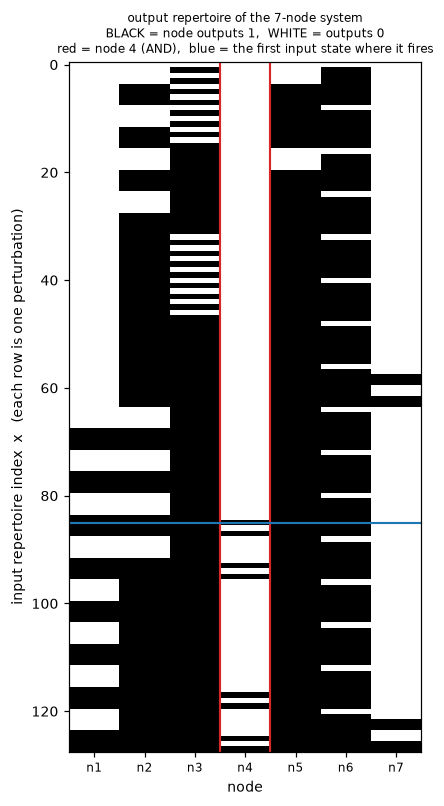

node 4 outputs 0 for the first 85 perturbations, then fires.

Two things to notice in the picture, both of which we will explain:
  1. node 4 (between the red lines) is blank above the blue line and
     sparsely striped below it -- a single threshold, then a pattern.
  2. every column repeats itself at several scales. Those repetitions are
     the offset family: the free coordinates a node cannot see, replaying
     the same short pattern over and over. The thesis calls this the
     fractal behaviour of the repertoire.


In [11]:
first1 = next(i for i, v in enumerate(node4) if v == 1)

fig, ax = plt.subplots(figsize=(4.0, 7.4))
ax.imshow(np.array(rep07), cmap='Greys', aspect='auto', interpolation='nearest')
ax.set_xticks(range(7)); ax.set_xticklabels([f'n{k+1}' for k in range(7)], fontsize=8)
ax.set_ylabel('input repertoire index  x   (each row is one perturbation)')
ax.set_xlabel('node')
ax.axvline(2.5, color='tab:red', lw=1.4); ax.axvline(3.5, color='tab:red', lw=1.4)
ax.axhline(first1, color='tab:blue', lw=1.4)
ax.annotate(f'x = {first1}', xy=(6.6, first1), color='tab:blue', fontsize=8,
            va='bottom', ha='right')
ax.set_title('output repertoire of the 7-node system\n'
             'BLACK = node outputs 1,  WHITE = outputs 0\n'
             'red = node 4 (AND),  blue = the first input state where it fires',
             fontsize=8)
plt.tight_layout(); plt.show()

print(f'node 4 outputs 0 for the first {first1} perturbations, then fires.')
print()
print('Two things to notice in the picture, both of which we will explain:')
print('  1. node 4 (between the red lines) is blank above the blue line and')
print('     sparsely striped below it -- a single threshold, then a pattern.')
print('  2. every column repeats itself at several scales. Those repetitions are')
print('     the offset family: the free coordinates a node cannot see, replaying')
print('     the same short pattern over and over. The thesis calls this the')
print('     fractal behaviour of the repertoire.')

### 3. PREDICT — where does that number come from?

Node 4 stays silent for a long stretch of the input repertoire and then fires.
The thesis's compressed behaviour formula for node 4 opens with exactly that
number:

$$85 \rightarrow 0,\ \{\{\{1 \rightarrow 1,\ 1 \rightarrow 0\}\} \rightarrow 2\},\ 4 \rightarrow 0\} \dots$$

read as *"85 occurrences of the digit 0, then twice the pattern 1,0, then 4
repetitions of 0…"*.

Node 4's index set is $\{1,3,5,7\}$ and its gate is `AND`.

**Where does 85 come from?**

In [12]:
PREDICT('Why is node 4 silent for exactly 85 perturbations?',
        ['85 is 128 minus 43, an artefact of the encoding',
         '85 is the sum of the decimal weights of its index set',
         '85 counts how many input states leave at least one of its inputs off',
         'it is a coincidence of this particular network'])

PREDICT  ->  Why is node 4 silent for exactly 85 perturbations?
            (1) 85 is 128 minus 43, an artefact of the encoding
            (2) 85 is the sum of the decimal weights of its index set
            (3) 85 counts how many input states leave at least one of its inputs off
            (4) it is a coincidence of this particular network
            commit to an answer, then run the next cell


### 4. Building the Behaviour Table, exactly as Chapter 4 defines it

The caption of Figure "Behaviour Tables" specifies the columns:

* **Node** — the input-nodes that feed the target node;
* **node−1 = pow** — the content of *Node* minus one, *"which determines the power
  to use"*;
* **2^(pow−1)** — *"the result of the binary to decimal transformation operation,
  equal to 2 powered by column node−1 = pow"*;
* a fourth column of **ratios between consecutive elements** of that column:
  at index $n$ its value is element $n{+}1$ divided by element $n$, so it looks
  *forward* and the final row is empty.

Two notes on reading the column names, which are mnemonics rather than formulae.
*node−1 = pow* means "take the Node number, subtract one, and that is the power
to use". The column then printed as *2^(pow−1)* holds $2^{\text{Node}-1}$, which
is $2^{\text{pow}}$ — the same number by two routes; the caption settles it by
saying the column *"is equal to 2 powered by column node−1 = pow"*.

That is the whole instrument. Let us build it.

In [13]:
def behaviour_table(net, k, gate):
    # Chapter 4's instrument, column by column, for target node k (0-based).
    ic = net.connected_inputs(k)                      # the pivots
    weights = [2 ** i for i in ic]
    rows = []
    for j, i in enumerate(ic):
        # The thesis defines the fourth column at index n as element[n+1] / element[n],
        # so it is forward-looking and the last row has no value.
        ratio = (weights[j + 1] // weights[j]) if j + 1 < len(weights) else None
        rows.append({
            'Node': i + 1,                            # 1-based, as in the thesis
            'node-1 = pow': i,
            '2^(pow-1)': 2 ** i,                      # = 2 ** (Node - 1) = 2 ** pow
            'element n+1 / element n': ratio,
        })
    return pd.DataFrame(rows), weights

bt4, w4 = behaviour_table(net07, 3, 'AND')
print('BEHAVIOUR TABLE for node 4   (gate: AND)')
display(bt4)
print('sum of the 2^(pow-1) column :', sum(w4))
print('smallest element            :', min(w4))
print('node 4 first fires at index :', first1)

BEHAVIOUR TABLE for node 4   (gate: AND)


,Node,node-1 = pow,2^(pow-1),element n+1 / element n
0,1,0,1,4.0
1,3,2,4,4.0
2,5,4,16,4.0
3,7,6,64,NaN


sum of the 2^(pow-1) column : 85
smallest element            : 1
node 4 first fires at index : 85


### 5. Reconciliation

**85 is the sum of the `2^(pow-1)` column.**

And the reason is now transparent. That column holds the *decimal weight* of each
pivot: node 1 contributes $2^0 = 1$, node 3 contributes $2^2 = 4$, node 5
contributes $2^4 = 16$, node 7 contributes $2^6 = 64$. Node 4's gate is `AND`, so
it fires only when **every** pivot is on simultaneously — and the smallest input
state in which that happens is the one whose decimal value is the sum of those
weights, $1 + 4 + 16 + 64 = 85$.

So the regularity the Behaviour Table exposes is not a curiosity of this network.
It is a rule. Let us check it on all seven nodes at once, and on `OR` as well as
`AND`.

In [14]:
rows = []
for k in range(7):
    ic = net07.connected_inputs(k)
    weights = [2 ** i for i in ic]
    col = [rep07[x][k] for x in range(128)]
    observed = next((i for i, v in enumerate(col) if v == 1), None)
    predicted = sum(weights) if dyn07[k] == 'AND' else min(weights)
    rows.append(dict(node=k + 1, gate=dyn07[k],
                     index_set=str([i + 1 for i in ic]),
                     weights=str(weights), sum=sum(weights), min=min(weights),
                     predicted_first_1=predicted, observed_first_1=observed,
                     agrees=predicted == observed))
check = pd.DataFrame(rows).set_index('node')
display(check)
print('rule holds on all seven nodes:', bool(check.agrees.all()))

,gate,index_set,weights,sum,min,predicted_first_1,observed_first_1,agrees
node,,,,,,,,
1,AND,"[3, 7]","[4, 64]",68,4,68,68,True
2,OR,"[3, 6]","[4, 32]",36,4,4,4,True
3,OR,"[1, 5, 7]","[1, 16, 64]",81,1,1,1,True
4,AND,"[1, 3, 5, 7]","[1, 4, 16, 64]",85,1,85,85,True
5,OR,"[3, 4, 6, 7]","[4, 8, 32, 64]",108,4,4,4,True
6,OR,"[1, 2, 3]","[1, 2, 4]",7,1,1,1,True
7,AND,"[2, 4, 5, 6]","[2, 8, 16, 32]",58,2,58,58,True


rule holds on all seven nodes: True


### 6. And this is where the formal method came from

Look at what we just wrote down, and then at Definition 3 of
`papers/method/manuscript_formal/method_paper.pdf`:

$$w(i) = 2^{\,i-1} \quad\text{(LSB-first bit weight)}, \qquad
P(\mathcal{I}_c) = \sum_{i \in \mathcal{I}_c} w(i) \quad\text{(the AND pivot)}.$$

The Behaviour Table's **`2^(pow-1)` column is $w(i)$**, and **its sum is
$P(\mathcal{I}_c)$**. The hand-made instrument from Chapter 4 and the formal
definition in the manuscript are the same object, and the "85" that was found by
eye in a printed table of ones and zeros is a closed-form quantity.

The rest of the method is the continuation of that move:

1. the pivots $\mathcal{I}_c$ give the **base set** $L = \{1 + P(\mathcal{I}_c)\}$;
2. the sumandos generate the **offset family** $\Omega$ — every combination of
   the free coordinates, which is why patterns *repeat* down the repertoire;
3. $\mathrm{Dec}(L, \Omega) = \{\ell + s\}$ unfolds the pair back into the exact
   set of repertoire indices where the node fires — with no row-by-row evaluation
   at all.

The compressed behaviour formula — *"85 zeros, then twice 1,0, then 4 zeros…"* —
was the human-readable ancestor of $\mathrm{Dec}(L,\Omega)$. Same content, found
by eye first and proved later.

In [15]:
# The full arc, on node 4: from pivots to the exact firing set, with no scanning.
ic4 = net07.connected_inputs(3)
inc4 = [i for i in range(7) if i not in ic4]          # the sumandos
P4 = sum(2 ** i for i in ic4)                         # the AND pivot
Omega = sorted(sum(2 ** i for i, b in zip(inc4, bits) if b)
               for bits in itertools.product([0, 1], repeat=len(inc4)))

predicted_firing = sorted(P4 + s for s in Omega)      # Dec({P}, Omega)
observed_firing = [x for x in range(128) if rep07[x][3] == 1]

print('index set I_c (nodes)    :', [i + 1 for i in ic4])
print('free coordinates I_nc    :', [i + 1 for i in inc4])
print('pivot P(I_c)             :', P4)
print('SUMANDOS (decimal offsets):', Omega, ' <- note 32, 34, 40, 42 exceed the node count')
print()
print('Dec({P}, Omega)  :', predicted_firing)
print('observed firing  :', observed_firing)
print()
print('exact match, with no row-by-row evaluation:', predicted_firing == observed_firing)
print(f'{len(observed_firing)} firing states derived from {len(Omega)} offsets and one pivot,')
print(f'instead of scanning all {2**7} rows.')

index set I_c (nodes)    : [1, 3, 5, 7]
free coordinates I_nc    : [2, 4, 6]
pivot P(I_c)             : 85
SUMANDOS (decimal offsets): [0, 2, 8, 10, 32, 34, 40, 42]  <- note 32, 34, 40, 42 exceed the node count

Dec({P}, Omega)  : [85, 87, 93, 95, 117, 119, 125, 127]
observed firing  : [85, 87, 93, 95, 117, 119, 125, 127]

exact match, with no row-by-row evaluation: True
8 firing states derived from 8 offsets and one pivot,
instead of scanning all 128 rows.


### 7. The tempting wrong answer

> *"A Behaviour Table is just another way of writing the output repertoire."*

It is not, and conflating them is exactly the mistake I made earlier in this
notebook. The output repertoire is the *measurement*. The Behaviour Table is a
*transformation applied to the measurement in order to see something* — it
introduces columns (`pow`, `2^(pow-1)`, ratios) that appear nowhere in the data
and exist only to make a pattern surface.

A second tempting error, subtler: *"so the Behaviour Table is the method"*. Also
no. Chapter 4 is explicit that it is scaffolding for intuition. The method is the
algebra it led to. Behaviour Tables were how the regularity was *found*;
$\mathrm{Dec}(L,\Omega)$ is how it is *proved and computed*. Confusing discovery
with justification would misrepresent both.

### 8. Takeaway and exercise

**Takeaway.** A Behaviour Table is an instrument of discovery: it transforms one
node's isolated output until its regularity is visible, and the regularity it
exposed — that the weights of the pivots determine where a node fires — became
the pivot $P(\mathcal{I}_c)$ and the operator $\mathrm{Dec}(L,\Omega)$ of the
formal method.

**Exercise.** Node 4 is `AND` and fires first at the *sum* of its weights; node 5
is `OR` and fires first at the *minimum*. Before running the cell: for an `XOR`
node, where would the first 1 appear — and would a single pivot number even be
enough to describe it?

In [16]:
# Your turn. Predict first, then run.
dyn_xor = ['AND', 'OR', 'OR', 'XOR', 'OR', 'OR', 'AND']
net_xor = cb.Network(n=7, C=cm07, gates=dyn_xor)
rep_xor = cb.repertoire(net_xor)
col = [rep_xor[x][3] for x in range(128)]
ic = net_xor.connected_inputs(3)
weights = [2 ** i for i in ic]

print('index set weights      :', weights)
print('first 1 at index       :', next(i for i, v in enumerate(col) if v == 1))
print('sum of weights         :', sum(weights), '   min of weights:', min(weights))
print('number of firing states:', sum(col), 'out of', len(col))
print()
print('XOR fires on odd parity of its pivots, so its one-set is a parity class,')
print('not a single band above a pivot -- see Section "parity classes" of the')
print('formal paper. One threshold number cannot describe it.')

index set weights      : [1, 4, 16, 64]
first 1 at index       : 1
sum of weights         : 85    min of weights: 1
number of firing states: 64 out of 128

XOR fires on odd parity of its pivots, so its one-set is a parity class,
not a single band above a pivot -- see Section "parity classes" of the
formal paper. One threshold number cannot describe it.


In [17]:
learned('Behaviour Table', 'an instrument that transforms an isolated output until its regularity shows',
        ('output repertoire',))
learned('behaviour formula', 'the compressed expression at the foot of a Behaviour Table',
        ('Behaviour Table',))
learned('bit weight w(i)', 'the decimal place value of coordinate i', ('input repertoire',))
learned('pivot P(I_c)', 'sum of the weights of the index set; where an AND node first fires',
        ('bit weight w(i)', 'index set / pivots'))
learned('offset family Omega', 'the sumandos: all subset sums of the free-coordinate weights',
        ('free coordinates I_nc', 'bit weight w(i)'))
learned('Dec(L, Omega)', 'unfolds base set + offsets into the exact firing set',
        ('pivot P(I_c)', 'offset family Omega'))
concept_map()

,idea,depends_on
input repertoire,all 2^n input states of the system,--
perturbation,flipping bits of an input state and re-running,input repertoire
output repertoire,what every node outputs for every input state,input repertoire
index set / pivots,the inputs a node actually depends on,"perturbation, output repertoire"
free coordinates I_nc,the nodes a query does not involve,index set / pivots
sumandos,DECIMAL offsets: every subset sum of the free ...,"free coordinates I_nc, bit weight w(i)"
gate,the function a node computes on its index set,index set / pivots
factorisation,a 2^n problem splits exactly into one 2^d prob...,"index set / pivots, free coordinates I_nc"
deconvolution,recovering index set and gate from behaviour a...,"output repertoire, factorisation"
Behaviour Table,an instrument that transforms an isolated outp...,output repertoire


---

# Question 0c — the second thing I got wrong, and what the method is actually *for*

*In Question 0 I labelled two individual bits "SUMANDO". That is wrong, and it
hides what the method is really doing. Table 4.14 of the thesis settles it.*

## **What are Sumandos really, and how do we ask a system questions?**

### 1. Intuition first

So far we have only asked one question: *what does this node depend on?* That is
the smallest question available. The method was built to answer much better ones:

* **"Where in the output repertoire does node 4 output 0?"**
* **"Where exactly does the pattern $(n_1,n_2,n_3) = (1,1,1)$ appear?"**
* **"Which output patterns can this system produce at all — and which are
  impossible?"**

For a 7-node system you could answer these by scanning 128 rows. For a 40-node
system there are $10^{12}$ rows and scanning is over. The method answers them
**without scanning**, by returning the answer in two pieces:

* a **DecimalRepertoire** $L$ — a handful of *anchor positions*, and
* a set of **Sumandos** $\Omega$ — a handful of *decimal offsets*.

The full answer is then every anchor plus every offset. Not a sample of it, and
not an approximation: the exact set.

**The mistake to clear up first.** Sumandos are **not** the disconnected nodes.
They are *numbers* — one for every combination of the free coordinates, obtained
by summing those coordinates' decimal weights $2^{i-1}$. In the example below
they include 32, 34, 40 and 42, in a system that only has seven nodes. If they
were nodes those values would be nonsense; as offsets into a 128-row repertoire
they are exactly right.

### 2. The concrete example — Table 4.14 of the thesis, verbatim

```mathematica
res070 = onPossibleBehaviour[{4}, {0}, dyn07, cm07]
gp     = givePlaces[res070["DecimalRepertoire"], res070["Sumandos"]]
```

*Read:* find the places in the output repertoire where node **4** takes the value
**0**. The published result is

```
DecimalRepertoire -> {0, 1, 4, 5, 16, 17, 20, 21, 64, 65, 68, 69, 80, 81, 84}
Sumandos          -> {0, 2, 8, 10, 32, 34, 40, 42}
```

Let us write the two functions from `src/integration/Alpha.m` transparently and
see whether we obtain the same thing.

In [18]:
def on_possible_behaviour(mechanism, substate, net):
    # Port of onPossibleBehaviour / findIndexesOfOutputs4Mechanism (Alpha.m).
    # mechanism: 1-based node indices being queried.  substate: required outputs.
    # 'joinedNames' is the union of the index sets of the queried nodes: the
    # coordinates the query actually involves.
    joined = sorted({i + 1 for k in mechanism for i in net.connected_inputs(k - 1)})

    # DecimalRepertoire: for every assignment of the involved coordinates that
    # satisfies the query, its decimal value.  These are the anchors.
    dec = []
    for bits in itertools.product([0, 1], repeat=len(joined)):
        assign = dict(zip(joined, bits))
        ok = True
        for k, want in zip(mechanism, substate):
            ic = net.connected_inputs(k - 1)
            got = cb.apply_gate(net.gates[k - 1], [assign[i + 1] for i in ic],
                                net.params[k - 1])
            if got != want:
                ok = False
                break
        if ok:
            dec.append(sum(2 ** (nd - 1) for nd, b in zip(joined, bits) if b))

    # Sumandos: Alpha.m computes
    #     sum      = 2^# & /@ (Complement[Range[n], joinedNames] - 1)
    #     sumandos = Total /@ Distribute[{{}, {#}} & /@ sum, ...]  // Sort
    # i.e. every SUBSET SUM of the weights of the coordinates not involved.
    free = [i for i in range(1, net.n + 1) if i not in joined]
    weights = [2 ** (i - 1) for i in free]
    sumandos = sorted({sum(c) for r in range(len(weights) + 1)
                       for c in itertools.combinations(weights, r)})
    return dict(AllInputNodes=joined, DecimalRepertoire=sorted(dec),
                FreeCoordinates=free, Sumandos=sumandos)


def give_places(decimal_repertoire, sumandos):
    # Port of givePlaces / unfoldLocationsAndSumandos (Alpha.m):
    # add the WHOLE sumandos list to EACH element of the DecimalRepertoire.
    return sorted(loc + s for loc in decimal_repertoire for s in sumandos)

res070 = on_possible_behaviour([4], [0], net07)
for key, val in res070.items():
    print(f'{key:18s}: {val}')

AllInputNodes     : [1, 3, 5, 7]
DecimalRepertoire : [0, 1, 4, 5, 16, 17, 20, 21, 64, 65, 68, 69, 80, 81, 84]
FreeCoordinates   : [2, 4, 6]
Sumandos          : [0, 2, 8, 10, 32, 34, 40, 42]


In [19]:
print('THESIS Table 4.14')
print('  DecimalRepertoire -> {0, 1, 4, 5, 16, 17, 20, 21, 64, 65, 68, 69, 80, 81, 84}')
print('  Sumandos          -> {0, 2, 8, 10, 32, 34, 40, 42}')
print()
print('OURS')
print('  DecimalRepertoire ->', res070['DecimalRepertoire'])
print('  Sumandos          ->', res070['Sumandos'])
print()
print('match:', res070['DecimalRepertoire'] == [0,1,4,5,16,17,20,21,64,65,68,69,80,81,84]
      and res070['Sumandos'] == [0,2,8,10,32,34,40,42])
print()
print('Note the free coordinates are nodes', res070['FreeCoordinates'],
      'with weights', [2**(i-1) for i in res070['FreeCoordinates']])
print('and the sumandos are every subset sum of those weights -- decimal offsets,')
print('which is why 32, 34, 40 and 42 appear in a system of only 7 nodes.')

THESIS Table 4.14
  DecimalRepertoire -> {0, 1, 4, 5, 16, 17, 20, 21, 64, 65, 68, 69, 80, 81, 84}
  Sumandos          -> {0, 2, 8, 10, 32, 34, 40, 42}

OURS
  DecimalRepertoire -> [0, 1, 4, 5, 16, 17, 20, 21, 64, 65, 68, 69, 80, 81, 84]
  Sumandos          -> [0, 2, 8, 10, 32, 34, 40, 42]

match: True

Note the free coordinates are nodes [2, 4, 6] with weights [2, 8, 32]
and the sumandos are every subset sum of those weights -- decimal offsets,
which is why 32, 34, 40 and 42 appear in a system of only 7 nodes.


### 3. PREDICT — before unfolding

The compressed answer has **15 anchors** and **8 sumandos**.

`givePlaces` adds the whole sumandos list to each anchor.

**How many positions of the 128-row output repertoire does that unfold to, and
what does the leftover tell you?**

In [20]:
PREDICT('How many places does 15 anchors x 8 sumandos unfold to?',
        ['15 + 8 = 23',
         '15 x 8 = 120, leaving 8 positions where node 4 outputs 1',
         '128, the whole repertoire',
         'it depends on overlaps between anchors and offsets'])

PREDICT  ->  How many places does 15 anchors x 8 sumandos unfold to?
            (1) 15 + 8 = 23
            (2) 15 x 8 = 120, leaving 8 positions where node 4 outputs 1
            (3) 128, the whole repertoire
            (4) it depends on overlaps between anchors and offsets
            commit to an answer, then run the next cell


In [21]:
places = give_places(res070['DecimalRepertoire'], res070['Sumandos'])
brute  = [x for x in range(128) if rep07[x][3] == 0]     # honest scan, for checking

print('unfolded places :', len(places), '=', len(res070['DecimalRepertoire']),
      'anchors x', len(res070['Sumandos']), 'sumandos')
print('brute-force scan:', len(brute))
print('identical       :', places == brute)
print()
print('first 24 unfolded:', places[:24])
print('positions NOT in the answer (so node 4 outputs 1 there):',
      [x for x in range(128) if x not in set(places)])
print()
print('...which is exactly the firing set Dec({P}, Omega) derived in Question 0b.')

unfolded places : 120 = 15 anchors x 8 sumandos
brute-force scan: 120
identical       : True

first 24 unfolded: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
positions NOT in the answer (so node 4 outputs 1 there): [85, 87, 93, 95, 117, 119, 125, 127]

...which is exactly the firing set Dec({P}, Omega) derived in Question 0b.


### 4. Reconciliation

**120 = 15 × 8**, and the 8 leftover positions are precisely where node 4 fires —
the same eight numbers we obtained in Question 0b from the pivot and the offset
family. The two routes agree, as they must.

Notice what did *not* happen: at no point did we evaluate 128 rows. We enumerated
$2^4 = 16$ assignments of the four involved coordinates, kept the 15 that
satisfy the query, and generated 8 offsets. The answer to a question about a
128-row object cost us 24 pieces of work — and the saving grows exponentially
with the number of free coordinates.

### 5. The two better questions

Now the same machinery, pointed at questions worth asking.

In [22]:
# "Where exactly does the pattern (n1, n2, n3) = (1,1,1) appear?"
q = on_possible_behaviour([1, 2, 3], [1, 1, 1], net07)
places111 = give_places(q['DecimalRepertoire'], q['Sumandos'])
truth111 = [x for x in range(128)
            if rep07[x][0] == 1 and rep07[x][1] == 1 and rep07[x][2] == 1]

print('QUERY: where is the output pattern (n1,n2,n3) = (1,1,1) ?')
print('  coordinates involved :', q['AllInputNodes'])
print('  DecimalRepertoire    :', q['DecimalRepertoire'])
print('  Sumandos             :', q['Sumandos'])
print('  unfolds to           :', len(places111), 'positions')
print('  agrees with a scan   :', places111 == truth111)
print('  places               :', places111)

QUERY: where is the output pattern (n1,n2,n3) = (1,1,1) ?
  coordinates involved : [1, 3, 5, 6, 7]
  DecimalRepertoire    : [68, 69, 84, 85, 100, 101, 116, 117]
  Sumandos             : [0, 2, 8, 10]
  unfolds to           : 32 positions
  agrees with a scan   : True
  places               : [68, 69, 70, 71, 76, 77, 78, 79, 84, 85, 86, 87, 92, 93, 94, 95, 100, 101, 102, 103, 108, 109, 110, 111, 116, 117, 118, 119, 124, 125, 126, 127]


In [23]:
# "Which output patterns are possible at all for these three nodes?"
print('QUERY: which patterns can (n1,n2,n3) ever take?')
rows = []
for patt in itertools.product([0, 1], repeat=3):
    r = on_possible_behaviour([1, 2, 3], list(patt), net07)
    n_places = len(r['DecimalRepertoire']) * len(r['Sumandos'])
    rows.append(dict(pattern=''.join(map(str, patt)),
                     anchors=len(r['DecimalRepertoire']),
                     sumandos=len(r['Sumandos']),
                     places=n_places,
                     reachable='yes' if n_places else 'NO -- impossible'))
poss = pd.DataFrame(rows).set_index('pattern')
display(poss)
print('total positions accounted for:', poss.places.sum(), 'of', 2 ** 7)
print()
print('Three of the eight patterns can never occur, whatever the input.')
print('That is a statement about the system, obtained without scanning it.')

QUERY: which patterns can (n1,n2,n3) ever take?


,anchors,sumandos,places,reachable
pattern,,,,
000,1,4,4,yes
001,7,4,28,yes
010,3,4,12,yes
011,13,4,52,yes
100,0,4,0,NO -- impossible
101,0,4,0,NO -- impossible
110,0,4,0,NO -- impossible
111,8,4,32,yes


total positions accounted for: 128 of 128

Three of the eight patterns can never occur, whatever the input.
That is a statement about the system, obtained without scanning it.


### 6. Why this is the point of the whole method

That last table is a **basin-of-attractor style answer**: which configurations the
system can and cannot reach. Three of eight patterns are unreachable, and we
learned it by enumerating five involved coordinates rather than 128 rows.

The scaling argument is the one that matters. The cost of these queries is set by
the number of *involved* coordinates, not by the size of the system. Free
coordinates cost nothing at all — they only multiply the answer, and that
multiplication is handled once, in closed form, by the sumandos. This is the same
factorisation as Question 0, now used to answer questions rather than to identify
a mechanism.

`Alpha.m` builds directly on this: `calculatingAttractors4Partition` simply runs
the loop above over all patterns of a partition, and returns every non-empty
answer in compressed $(L, \Omega)$ form.

### 7. The tempting wrong answers

> *"Sumandos are the disconnected nodes."*

No — that was my error, and Table 4.14 refutes it on sight: the sumandos are
$\{0,2,8,10,32,34,40,42\}$ in a system with seven nodes. The *free coordinates*
are the nodes $\{2,4,6\}$; the sumandos are the eight subset sums of their
weights $\{2,8,32\}$. Nodes and offsets are different kinds of object, and the
whole compression lives in the offsets.

> *"The compressed form is a summary, so unfolding must lose something."*

It loses nothing. `givePlaces` reconstructs the answer set exactly, as the
`identical: True` above shows. $(L, \Omega)$ is a *factorisation* of the answer,
not a digest of it — which is why the operation is called deconvolution rather
than compression.

### 8. Takeaway and exercise

**Takeaway.** A query returns two lists: **DecimalRepertoire**, the anchors from
the coordinates the query involves, and **Sumandos**, the decimal offsets
generated by every combination of the coordinates it does not. Adding the whole
of the second to each element of the first unfolds the exact answer. Sumandos are
numbers, not nodes.

**Exercise.** Query node 5 for the value 1. Before running: node 5's index set is
$\{3,4,6,7\}$, so three coordinates are free. How many sumandos will there be,
and how many anchors would make the answer cover the whole repertoire?

In [24]:
# Your turn. Predict first, then run.
r5 = on_possible_behaviour([5], [1], net07)
pl5 = give_places(r5['DecimalRepertoire'], r5['Sumandos'])
print('involved coordinates :', r5['AllInputNodes'])
print('free coordinates     :', r5['FreeCoordinates'])
print('anchors              :', len(r5['DecimalRepertoire']), r5['DecimalRepertoire'])
print('sumandos             :', len(r5['Sumandos']), r5['Sumandos'])
print('unfolds to           :', len(pl5), 'places')
print('agrees with a scan   :', pl5 == [x for x in range(128) if rep07[x][4] == 1])

involved coordinates : [3, 4, 6, 7]
free coordinates     : [1, 2, 5]
anchors              : 15 [4, 8, 12, 32, 36, 40, 44, 64, 68, 72, 76, 96, 100, 104, 108]
sumandos             : 8 [0, 1, 2, 3, 16, 17, 18, 19]
unfolds to           : 120 places
agrees with a scan   : True


In [25]:
learned('onPossibleBehaviour', 'query: where does this pattern occur in the output repertoire?',
        ('output repertoire', 'index set / pivots'))
learned('DecimalRepertoire L', 'anchor positions from the coordinates a query involves',
        ('onPossibleBehaviour', 'bit weight w(i)'))
learned('givePlaces', 'unfold: add the whole sumandos list to each anchor',
        ('DecimalRepertoire L', 'sumandos'))
learned('possible outputs', 'which patterns a system can reach, and which are impossible',
        ('onPossibleBehaviour',))
concept_map()

,idea,depends_on
input repertoire,all 2^n input states of the system,--
perturbation,flipping bits of an input state and re-running,input repertoire
output repertoire,what every node outputs for every input state,input repertoire
index set / pivots,the inputs a node actually depends on,"perturbation, output repertoire"
free coordinates I_nc,the nodes a query does not involve,index set / pivots
sumandos,DECIMAL offsets: every subset sum of the free ...,"free coordinates I_nc, bit weight w(i)"
gate,the function a node computes on its index set,index set / pivots
factorisation,a 2^n problem splits exactly into one 2^d prob...,"index set / pivots, free coordinates I_nc"
deconvolution,recovering index set and gate from behaviour a...,"output repertoire, factorisation"
Behaviour Table,an instrument that transforms an isolated outp...,output repertoire


---

## Your turn

That was the format, and the terminology is now on a firm footing. Ask your first
question.

Directions that would follow naturally, though ask whatever you actually want:

* *What is algorithmic complexity, and why can it not simply be computed?*
* *What is BDM actually doing when it chops a matrix into 4×4 blocks?*
  — this one now has a full answer of its own in `understanding_bdm.ipynb`,
  including why "it counts blocks" is wrong and where the size confound really
  comes from.
* *Why does a molecule become a Boolean network at all — is that not arbitrary?*
* *What is the PUM really measuring, and why do I distrust it?*
* *Why did the paper's complexity measure turn out to be mostly molecule size?*
* *What is an "invariant", and why did so much of the argument hinge on it?*